<a href="https://colab.research.google.com/github/pengin-cmd/my-colab-notebooks/blob/main/%E3%82%B3%E3%83%B3%E3%83%9A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install xgboost catboost optuna lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 29.0 MB/s eta 0:00:00


In [4]:
!pip install optuna

In [5]:
pip install lifetimes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 4.3 MB/s eta 0:00:00



--- [1. Optuna パラメータ最適化 (バックグラウンド実行)] ---

--- [2. 学習フェーズ開始 (真のリークフリー版スタッキング)] ---
>> Running Seed: 42...
   🧠 Seed 42 専用の司令塔（メタモデル）の純粋なOOF予測を計算中...
   ↳ 最終重み配分 -> LightGBM: 2.884 | XGBoost: 0.744 | RandomForest: 1.066
>> Running Seed: 2023...
   🧠 Seed 2023 専用の司令塔（メタモデル）の純粋なOOF予測を計算中...
   ↳ 最終重み配分 -> LightGBM: 1.600 | XGBoost: 1.243 | RandomForest: 2.222
>> Running Seed: 777...
   🧠 Seed 777 専用の司令塔（メタモデル）の純粋なOOF予測を計算中...
   ↳ 最終重み配分 -> LightGBM: 1.875 | XGBoost: 1.324 | RandomForest: 1.967
✅ 学習完了: 真のリークフリー・マルチシードスタッキングが完了しました。

--- [3. 予測フェーズ開始] ---
✅ 予測完了: リークフリーなスタッキング予測を安全に出力しました。

--- [4. エラー分析 (損失原因の特定)] ---
▼ 全体のエラー件数 (is_error = 1): 210 件 / 1568 件

▼ 損失原因度ランキング トップ5:
                    Feature  Error_Importance
0            recent_loyalty         14.953178
1         campaign_affinity          8.952531
2                spend_gold          7.719847
3   days_since_registration          7.703537
4  days_since_last_purchase          7.188386

--- [5. 特徴量重要度の算出] ---


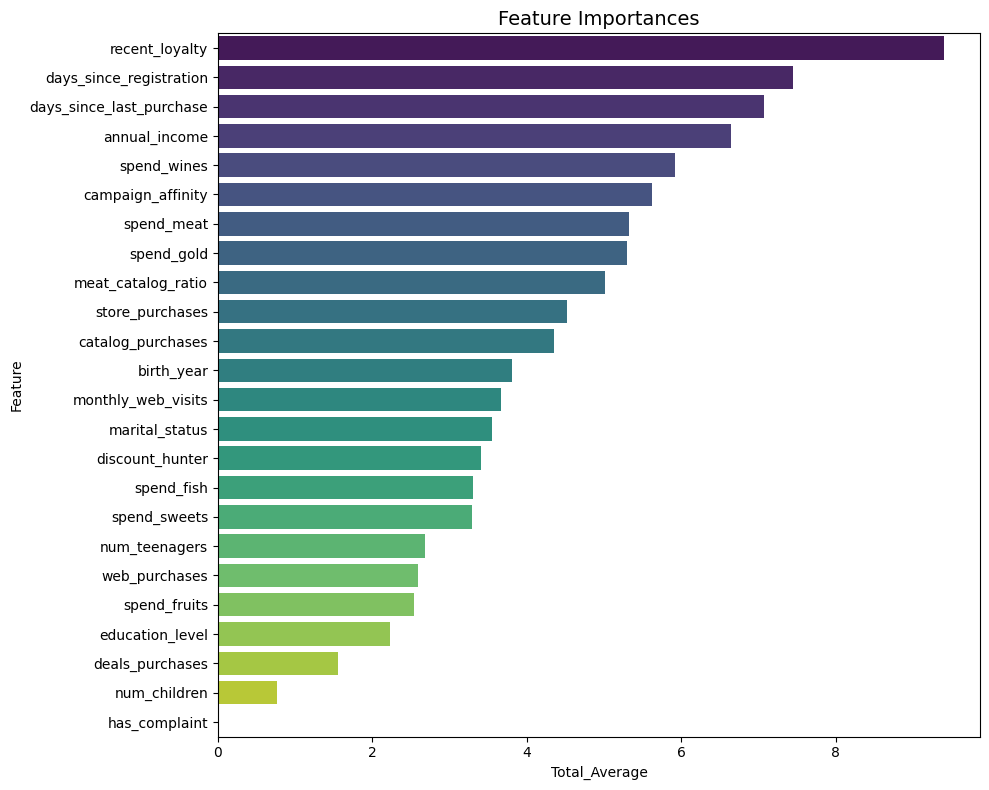


✅ 全工程完了: 'final_submission_perfect_stacked.csv' を出力しました！


In [15]:
import pandas as pd
import numpy as np
import warnings
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier, export_text
from lightgbm import LGBMClassifier, early_stopping
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ==========================================
# 0. 絶対にリークしない事前処理（result_4ベース）
# ==========================================
def preprocess_safe_row_wise(df):
    df = df.copy()
    base_date = pd.to_datetime('2015-01-01')

    if 'registration_date' in df.columns:
        df['days_since_registration'] = (base_date - pd.to_datetime(df['registration_date'])).dt.days
        df = df.drop('registration_date', axis=1)

    # --- 💡 特徴量エンジニアリング（result_4のエース特徴量のみ） ---
    if all(c in df.columns for c in ['spend_wines', 'spend_meat', 'days_since_last_purchase']):
        df['recent_loyalty'] = (df['spend_wines'] + df['spend_meat']) / (df['days_since_last_purchase'] + 1)

    if all(c in df.columns for c in ['spend_meat', 'catalog_purchases']):
        df['meat_catalog_ratio'] = df['spend_meat'] / (df['catalog_purchases'] + 1)

    if all(c in df.columns for c in ['deals_purchases', 'store_purchases', 'web_purchases', 'catalog_purchases']):
        total_purchases = df['store_purchases'] + df['web_purchases'] + df['catalog_purchases']
        df['discount_hunter'] = df['deals_purchases'] / (total_purchases + 1)
        if 'recent_loyalty' in df.columns:
            df['campaign_affinity'] = df['recent_loyalty'] * df['discount_hunter']

    return df

# ==========================================
# 1. Optuna パラメータ最適化
# ==========================================
def tune_lightgbm_with_optuna(X_raw, y, n_trials=10):
    print("\n--- [1. Optuna パラメータ最適化 (バックグラウンド実行)] ---")
    def objective(trial):
        params = {
            'random_state': 42,
            'n_estimators': 500,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'num_leaves': trial.suggest_int('num_leaves', 15, 63),
            'class_weight': 'balanced',
            'verbose': -1
        }
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        oof = np.zeros(len(X_raw))
        for tr_idx, va_idx in skf.split(X_raw, y):
            X_tr, y_tr = X_raw.iloc[tr_idx].copy(), y.iloc[tr_idx]
            X_va, y_va = X_raw.iloc[va_idx].copy(), y.iloc[va_idx]
            med = X_tr['annual_income'].median()
            X_tr['annual_income'] = X_tr['annual_income'].fillna(med)
            X_va['annual_income'] = X_va['annual_income'].fillna(med)
            cols = ['education_level', 'marital_status']
            enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            X_tr[cols] = enc.fit_transform(X_tr[cols])
            X_va[cols] = enc.transform(X_va[cols])
            model = LGBMClassifier(**params)
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[early_stopping(stopping_rounds=30, verbose=False)])
            oof[va_idx] = model.predict_proba(X_va)[:, 1]
        return roc_auc_score(y, oof)

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)
    best_params = study.best_params
    best_params.update({'random_state': 42, 'n_estimators': 1000, 'class_weight': 'balanced', 'verbose': -1})
    return best_params

# ==========================================
# 2. 学習フェーズ (シードごとに完全隔離されたスタッキング)
# ==========================================
def train_models_leakfree(X_raw, y, lgb_best_params, seeds=[42, 2023, 777], n_splits=5):
    print(f"\n--- [2. 学習フェーズ開始 (真のリークフリー版スタッキング)] ---")
    artifacts = []
    ratio = float(np.sum(y == 0)) / np.sum(y == 1)

    # 分析グラフ用の予測値配列（可視化用）
    visualization_oof = np.zeros(len(X_raw))

    for seed in seeds:
        print(f">> Running Seed: {seed}...")
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

        # 🌟 このシード内「だけ」の独立したOOF予測器
        seed_oof_lgb = np.zeros(len(X_raw))
        seed_oof_xgb = np.zeros(len(X_raw))
        seed_oof_rf  = np.zeros(len(X_raw))

        seed_models_archive = []

        for fold, (train_idx, val_idx) in enumerate(skf.split(X_raw, y)):
            X_tr, y_tr = X_raw.iloc[train_idx].copy(), y.iloc[train_idx]
            X_va, y_va = X_raw.iloc[val_idx].copy(), y.iloc[val_idx]

            income_median = X_tr['annual_income'].median()
            X_tr['annual_income'] = X_tr['annual_income'].fillna(income_median)
            X_va['annual_income'] = X_va['annual_income'].fillna(income_median)

            categorical_cols = ['education_level', 'marital_status']
            encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            X_tr[categorical_cols] = encoder.fit_transform(X_tr[categorical_cols])
            X_va[categorical_cols] = encoder.transform(X_va[categorical_cols])

            lgb_params = lgb_best_params.copy()
            lgb_params['random_state'] = seed

            models = {
                'LightGBM': LGBMClassifier(**lgb_params),
                'XGBoost': XGBClassifier(random_state=seed, n_estimators=1000, learning_rate=0.05, max_depth=5, scale_pos_weight=ratio, early_stopping_rounds=50, eval_metric='logloss'),
                'RandomForest': RandomForestClassifier(random_state=seed, n_estimators=100, max_depth=10, class_weight='balanced')
            }

            models['LightGBM'].fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[early_stopping(stopping_rounds=30, verbose=False)])
            models['XGBoost'].fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
            models['RandomForest'].fit(X_tr, y_tr)

            # 🌟 他のシードと混ぜずに、このシードの配列だけに記録
            seed_oof_lgb[val_idx] = models['LightGBM'].predict_proba(X_va)[:, 1]
            seed_oof_xgb[val_idx] = models['XGBoost'].predict_proba(X_va)[:, 1]
            seed_oof_rf[val_idx]  = models['RandomForest'].predict_proba(X_va)[:, 1]

            seed_models_archive.append({
                'fold': fold,
                'preprocessors': {'income_median': income_median, 'encoder': encoder, 'cat_cols': categorical_cols},
                'models': models
            })

        # 🌟 このシードが持つ5つのFoldの予測がすべて出揃った段階で、このシード専用の司令塔を学習させる
     # ==========================================
        # 🌟 メタモデル（司令塔）の学習とリークフリーな評価
        # ==========================================
        print(f"   🧠 Seed {seed} 専用の司令塔（メタモデル）の純粋なOOF予測を計算中...")
        meta_X_seed = pd.DataFrame({'LightGBM': seed_oof_lgb, 'XGBoost': seed_oof_xgb, 'RandomForest': seed_oof_rf})

        # 💡 【修正ポイント】評価・エラー分析用のOOFを出すために、司令塔自身もCV（分割テスト）で回す！
        meta_oof_seed = np.zeros(len(X_raw))
        skf_meta = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

        for tr_m_idx, va_m_idx in skf_meta.split(meta_X_seed, y):
            m_tr_x, m_tr_y = meta_X_seed.iloc[tr_m_idx], y.iloc[tr_m_idx]
            m_va_x = meta_X_seed.iloc[va_m_idx]

            # 一時的な評価用司令塔
            temp_meta = LogisticRegression(random_state=42)
            temp_meta.fit(m_tr_x, m_tr_y)
            # カンニング一切なしの純粋な予測値だけを記録
            meta_oof_seed[va_m_idx] = temp_meta.predict_proba(m_va_x)[:, 1]

        # エラー分析グラフ用には、この純粋なOOF（カンニングなし）だけを足し合わせる
        visualization_oof += meta_oof_seed / len(seeds)

        # ------------------------------------------
        # テストデータ推論用の「本番用司令塔」は、堂々と全OOFデータで学習させる
        meta_model_seed = LogisticRegression(random_state=42)
        meta_model_seed.fit(meta_X_seed, y)

        w = meta_model_seed.coef_[0]
        print(f"   ↳ 最終重み配分 -> LightGBM: {w[0]:.3f} | XGBoost: {w[1]:.3f} | RandomForest: {w[2]:.3f}")

        artifacts.append({
            'seed': seed,
            'base_models': seed_models_archive,
            'meta_model': meta_model_seed,
            'feature_names': list(X_raw.columns)
        })

    print(f"✅ 学習完了: 真のリークフリー・マルチシードスタッキングが完了しました。")
    return artifacts, visualization_oof

# ==========================================
# 3. 予測フェーズ (未知のデータへの適用)
# ==========================================
def predict_models_leakfree(X_test_raw, artifacts):
    print("\n--- [3. 予測フェーズ開始] ---")
    final_test_preds = np.zeros(len(X_test_raw))

    # 各シード（司令塔）ごとに独立して予測を計算し、最後に平均を取る
    for art in artifacts:
        seed = art['seed']
        meta_model = art['meta_model']
        base_models_archive = art['base_models']

        # このシード内のベースモデル群の予測を平均するための配列
        test_lgb_seed = np.zeros(len(X_test_raw))
        test_xgb_seed = np.zeros(len(X_test_raw))
        test_rf_seed  = np.zeros(len(X_test_raw))
        n_folds = len(base_models_archive)

        for fold_data in base_models_archive:
            X_te = X_test_raw.copy()
            preps = fold_data['preprocessors']
            models = fold_data['models']

            X_te['annual_income'] = X_te['annual_income'].fillna(preps['income_median'])
            X_te[preps['cat_cols']] = preps['encoder'].transform(X_te[preps['cat_cols']])

            test_lgb_seed += models['LightGBM'].predict_proba(X_te)[:, 1] / n_folds
            test_xgb_seed += models['XGBoost'].predict_proba(X_te)[:, 1] / n_folds
            test_rf_seed  += models['RandomForest'].predict_proba(X_te)[:, 1] / n_folds

        # このシードの司令塔に最終判断をさせる
        meta_X_test_seed = pd.DataFrame({'LightGBM': test_lgb_seed, 'XGBoost': test_xgb_seed, 'RandomForest': test_rf_seed})
        seed_final_pred = meta_model.predict_proba(meta_X_test_seed)[:, 1]

        # 全シードの最終判断を平均化
        final_test_preds += seed_final_pred / len(artifacts)

    print(f"✅ 予測完了: リークフリーなスタッキング予測を安全に出力しました。")
    return final_test_preds

# ==========================================
# 4 & 5. 可視化・分析 (変更なし)
# ==========================================
def analyze_error_patterns(X_raw, y, oof_preds):
    print("\n--- [4. エラー分析 (損失原因の特定)] ---")
    error_df = X_raw.copy()
    error_df['target'] = y
    error_df['pred_class'] = (oof_preds >= 0.5).astype(int)
    error_df['is_error'] = (error_df['target'] != error_df['pred_class']).astype(int)
    print(f"▼ 全体のエラー件数 (is_error = 1): {error_df['is_error'].sum()} 件 / {len(error_df)} 件")

    X_error = X_raw.copy()
    X_error['annual_income'] = X_error['annual_income'].fillna(X_error['annual_income'].median())
    cols = ['education_level', 'marital_status']
    X_error[cols] = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1).fit_transform(X_error[cols])
    error_model = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, class_weight='balanced')
    error_model.fit(X_error, error_df['is_error'])
    error_importance = pd.DataFrame({'Feature': X_error.columns, 'Error_Importance': error_model.feature_importances_ * 100}).sort_values(by='Error_Importance', ascending=False).reset_index(drop=True)
    print("\n▼ 損失原因度ランキング トップ5:")
    print(error_importance.head(5))
    return error_importance

def plot_feature_importances(artifacts):
    print("\n--- [5. 特徴量重要度の算出] ---")
    f_names = artifacts[0]['feature_names']
    importance_df = pd.DataFrame({'Feature': f_names})
    total_imps = np.zeros(len(f_names))
    total_models = 0
    scaler = MinMaxScaler()
    for art in artifacts:
        for fold_data in art['base_models']:
            for name, model in fold_data['models'].items():
                raw_imp = model.feature_importances_
                scaled_imp = scaler.fit_transform(raw_imp.reshape(-1, 1)).flatten()
                total_imps += scaled_imp
                total_models += 1
    importance_df['Total_Average'] = (total_imps / total_models)
    importance_df['Total_Average'] = (importance_df['Total_Average'] / importance_df['Total_Average'].sum()) * 100
    importance_df = importance_df.sort_values(by='Total_Average', ascending=False).reset_index(drop=True)
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Total_Average', y='Feature', data=importance_df, palette='viridis')
    plt.title('Feature Importances', fontsize=14)
    plt.tight_layout()
    plt.show()

# ==========================================
# メイン実行ブロック
# ==========================================
if __name__ == "__main__":
    train_data = pd.read_csv('train.csv')
    test_data = pd.read_csv('test.csv')

    train_df = preprocess_safe_row_wise(train_data)
    test_df = preprocess_safe_row_wise(test_data)

    X_raw = train_df.drop(['customer_id', 'target'], axis=1)
    y = train_df['target']
    X_test_raw = test_df.drop(['customer_id'], axis=1, errors='ignore')

    best_lgb_params = tune_lightgbm_with_optuna(X_raw, y, n_trials=10)

    # 🌟 修正されたリークフリー関数を呼び出し
    artifacts, oof_predictions = train_models_leakfree(X_raw, y, best_lgb_params)
    final_predictions = predict_models_leakfree(X_test_raw, artifacts)

    analyze_error_patterns(X_raw, y, oof_predictions)
    plot_feature_importances(artifacts)

    submission = pd.DataFrame({'customer_id': test_data['customer_id'], 'target': final_predictions})
    submission.to_csv('final_submission_perfect_stacked.csv', index=False)
    print("\n✅ 全工程完了: 'final_submission_perfect_stacked.csv' を出力しました！")